In [ ]:
!pip install jsonlines
!pip install seaborn

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Data Load

Only used the ips checked with Shodan

In [ ]:
from pathlib import Path
DATA_FOLDER = Path('/content/drive/MyDrive/DSCI599/data')

## Load checked ips

In [ ]:
with open(DATA_FOLDER / "checked.txt", 'r') as f:
  checked_history = f.read().strip().split("\n")

len(checked_history)
checked_history = set(checked_history)

In [ ]:
import ipaddress
checked_history_int = [int(ipaddress.ip_address(ip)) for ip in checked_history]
checked_history_int[0]

3396060922

# Load Shodan Data

In [ ]:
import jsonlines

shodan_data = []
with jsonlines.open(DATA_FOLDER / "shodan.jsonl", mode="r") as reader:
  for x in reader:
    shodan_data.append(x)

len(shodan_data)

257

In [ ]:
shodan_ips = [x['ip'] for x in shodan_data]
print(len(shodan_ips))

257


In [ ]:
import ipaddress
shodan_ips_int = [int(ipaddress.ip_address(ip)) for ip in shodan_ips]

## Load data

In [ ]:
import ipaddress
import datetime
import pandas as pd


# glob all files ending with strategy
# hourly_files = list(DATA_FOLDER.glob("*.strategy"))
# only use one data for now, because it takes too long to use shodan to scan all
hourly_files = [DATA_FOLDER / "1464217200.strategy"]


hourly_columns = [
    "source_ip",
    "num_scanned_destination_ips",
    "num_unique_flows",
    "num_packets",
    "timestamp_first_activity",
    "timestamp_last_activity",
    "same_packet_size_flag",
    "avg_packet_size",
    "num_unique_Bs_scanned",
    "num_unique_Cs_scanned",
    "num_unique_Ds_scanned",
    "num_scanned_24_blocks",
    "num_non_conficker_destinations",
    "ip_address_range_diff",
    "destination_port",
    "protocol"
]

hourly_df = []
hourly_timestamps = []
for f in hourly_files:
  df = pd.read_csv(f, sep='|', header=None, names=hourly_columns)

  timestamp = int(f.stem)
  dt = str(datetime.datetime.fromtimestamp(timestamp))
  df.name = dt
  hourly_df.append(df)

  hourly_timestamps.append(dt)

def clean_df(df: pd.DataFrame) -> pd.DataFrame:
  """
  preprocess df function for reprocudibility
  """

  drop_columns = [
    "timestamp_first_activity",
    "timestamp_last_activity",
    "ip_address_range_diff"
    ]

  # ip set to int and set ip as index
  df['int_source_ip'] = df['source_ip'].map(lambda ip: int(ipaddress.ip_address(ip)))
  df = df.drop(columns = ['source_ip'])
  # df = df.set_index('int_source_ip')

  # get activity time
  df['time_activity'] = df['timestamp_last_activity'] - df['timestamp_first_activity']

  df = df.drop(columns = drop_columns)

  # only use ips that have been checked
  df = df[df['int_source_ip'].isin(checked_history_int)]
  return df

def add_labels(df: pd.DataFrame, compromised_ips: list) -> pd.DataFrame:
  df['compromised'] = 0
  df.loc[df['int_source_ip'].isin(compromised_ips), 'compromised'] = 1

  return df

for i in range(len(hourly_df)):
  df = hourly_df[i].copy()
  df = clean_df(df)
  df = add_labels(df, compromised_ips=shodan_ips_int)

  hourly_df[i] = df

In [ ]:
hourly_df[0].head()

,num_scanned_destination_ips,num_unique_flows,num_packets,same_packet_size_flag,avg_packet_size,num_unique_Bs_scanned,num_unique_Cs_scanned,num_unique_Ds_scanned,num_scanned_24_blocks,num_non_conficker_destinations,destination_port,protocol,int_source_ip,time_activity,compromised
0,161,161,490,1,60.0,118,112,124,161,39,23,6,3065676419,780,0
1,512,512,1045,1,29.0,2,2,256,2,128,53413,17,3200595405,60,0
2,255,255,255,1,60.0,1,1,255,1,128,23,6,3153160574,240,0
3,238,238,238,1,60.0,153,152,160,238,66,0,1,2948693889,3480,1
4,255,255,255,1,60.0,1,1,255,1,128,23,6,3383600711,240,0


In [ ]:
hourly_df[0]['compromised'].value_counts()

,count
compromised,
0,5043
1,2555


# Explanatory Data Analysis

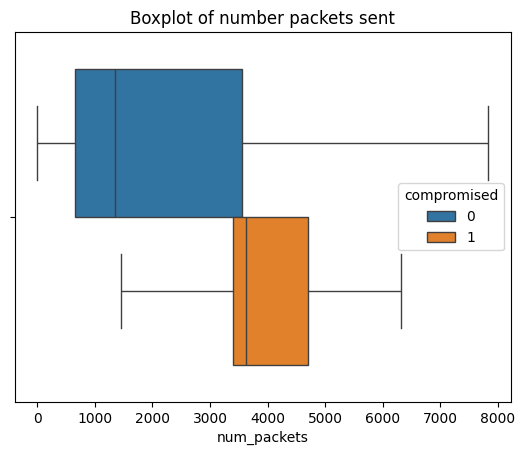

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(df,
            x='num_packets',
            hue='compromised',
            showfliers=False)
plt.title('Boxplot of number packets sent')
plt.show()

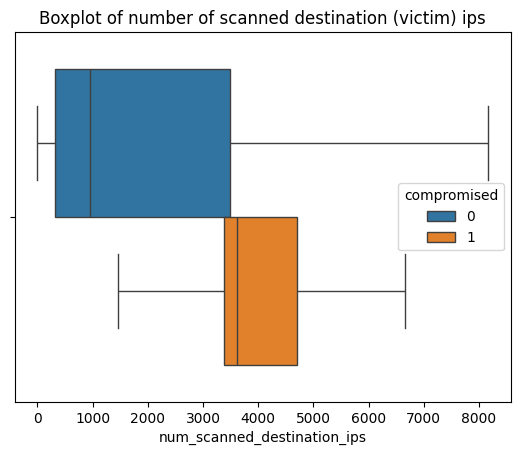

In [ ]:
sns.boxplot(df,
            x='num_scanned_destination_ips',
            hue='compromised',
            showfliers=False)
plt.title('Boxplot of number of scanned destination (victim) ips')
plt.show()

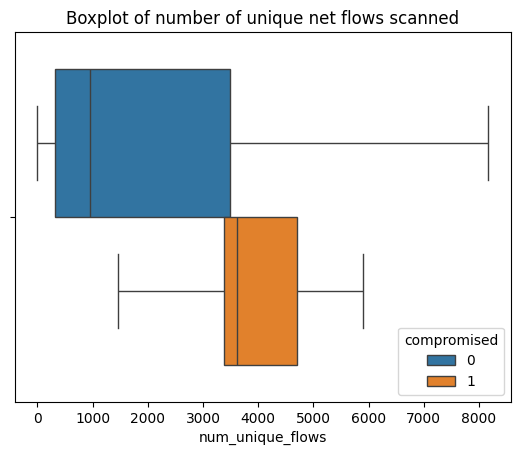

In [ ]:
sns.boxplot(df,
            x='num_unique_flows',
            hue='compromised',
            showfliers=False)

plt.title('Boxplot of number of unique net flows scanned')

plt.show()

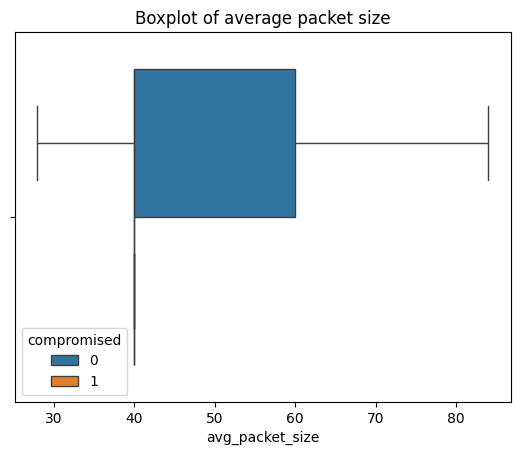

In [ ]:
sns.boxplot(df,
            x='avg_packet_size',
            hue='compromised',
            showfliers=False)

plt.title('Boxplot of average packet size')

plt.show()

<Axes: xlabel='num_non_conficker_destinations'>

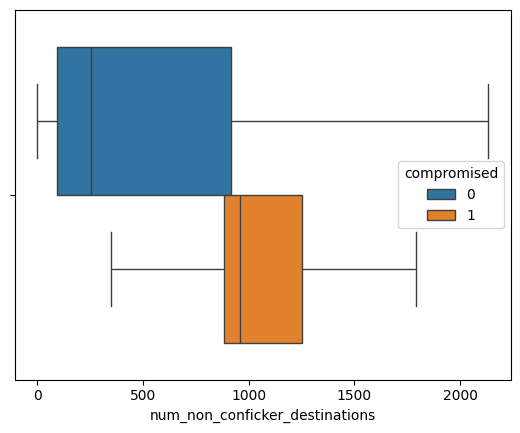

In [ ]:
sns.boxplot(df,
            x = "num_non_conficker_destinations",
            hue="compromised",
            showfliers=False)
plt.title("Boxplot of average ")
plt.show()

## Correlation plot

Multi-collinearity is pretty bad for ML and DL as well

> https://seaborn.pydata.org/examples/many_pairwise_correlations.html

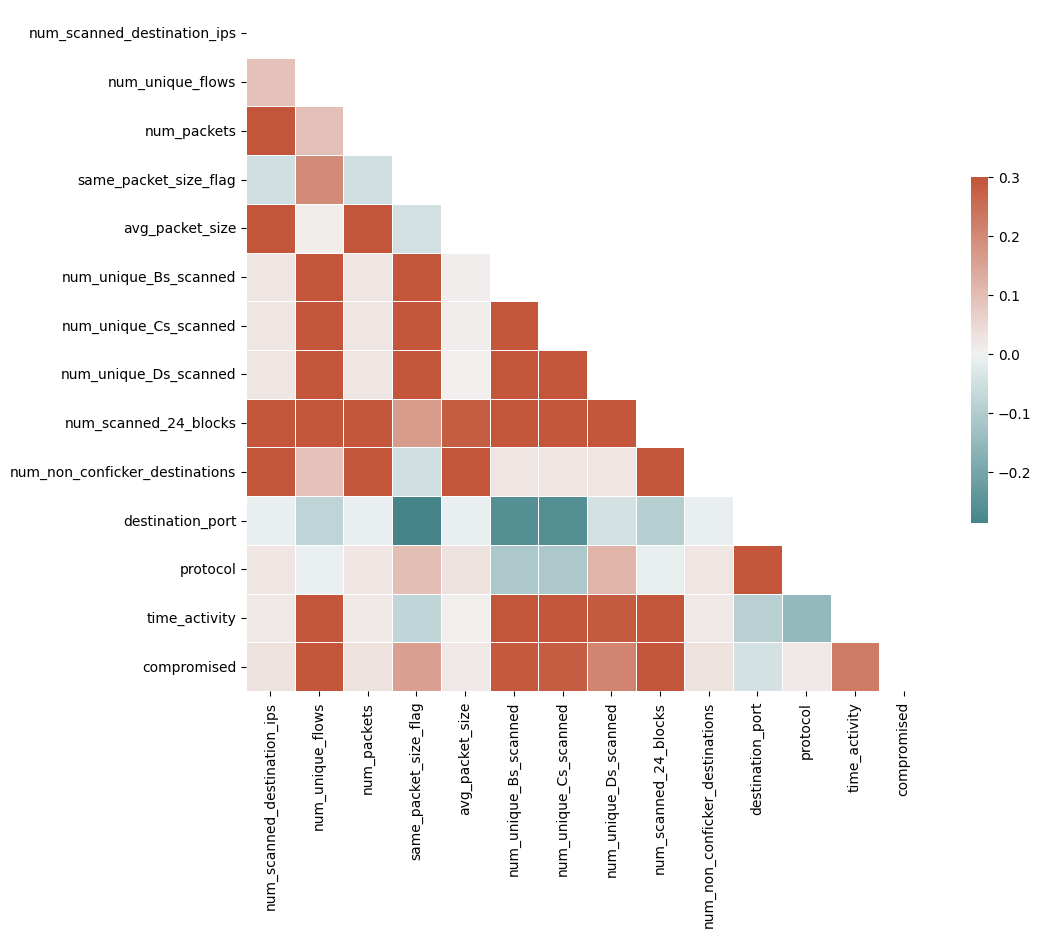

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

feat_df = df.drop(columns=['int_source_ip']) # keep compromised to see corr
corr = feat_df.corr()
# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(11, 9))

# Generate a custom diverging colormap
cmap = sns.diverging_palette(200, 20, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})

plt.show()

Observations:
- Protocol and Destination port has a positive correlation
-

Could remove some columns, specifically:

```
remove= [
  "num_scanned_24_blocks"
]
```

In [ ]:
remove= [
  "num_scanned_24_blocks"
]

for i in range(len(hourly_df)):
  df = hourly_df[i]
  df = df.drop(columns=remove)
  hourly_df[i]

In [ ]:
hourly_df[0].head()

,num_scanned_destination_ips,num_unique_flows,num_packets,same_packet_size_flag,avg_packet_size,num_unique_Bs_scanned,num_unique_Cs_scanned,num_unique_Ds_scanned,num_scanned_24_blocks,num_non_conficker_destinations,destination_port,protocol,int_source_ip,time_activity,compromised
0,161,161,490,1,60.0,118,112,124,161,39,23,6,3065676419,780,0
1,512,512,1045,1,29.0,2,2,256,2,128,53413,17,3200595405,60,0
2,255,255,255,1,60.0,1,1,255,1,128,23,6,3153160574,240,0
3,238,238,238,1,60.0,153,152,160,238,66,0,1,2948693889,3480,1
4,255,255,255,1,60.0,1,1,255,1,128,23,6,3383600711,240,0


# Output CSV

In [ ]:
import datetime
for df, dt in zip(hourly_df, hourly_timestamps):
  dt = datetime.datetime.strptime(dt, "%Y-%m-%d %H:%M:%S")
  dt = int(dt.timestamp())
  output_path = DATA_FOLDER / f"{dt}.csv"
  df.to_csv(output_path, index=False)

# Unused code

did json.dump over and over and it resulted in a mess of data, so this s code I did to fix it

In [ ]:
import jsonlines
with open(DATA_FOLDER / "shodan_old.json", "r") as f:
  lines = f.read()
split = lines.split("][")
valid = [0, 1, 9, 10]


In [ ]:
valid_json = []
valid_json.append(split[0] + "]")
valid_json.append("["+"][".join(split[1:9])+"]")
valid_json.append("["+split[9]+"]")
valid_json.append("["+"][".join(split[10:16]))

In [ ]:
import json
valid_dicts = []
for i, x in enumerate(valid_json):
  print(i)
  valid_dicts.append(json.loads(x))

0
1
2
3


In [ ]:
c=0
for x in valid_dicts:
  print(type(x))
  c+=len(x)
c

<class 'list'>
<class 'list'>
<class 'list'>
<class 'list'>


257

In [ ]:
out_list = []
for x in valid_dicts:
  out_list.extend(x)

In [ ]:
import jsonlines

with jsonlines.open(DATA_FOLDER / "shodan.jsonl", mode="w") as writer:
  writer.write_all(out_list)

In [ ]:
valid_json = []
prev_i = -1

for i in valid:
  if i == 0:
    valid_json.append()
  else:
    valid_json.append(split[prev_i: ])

  prev_i = i

## current checked

To keep reprocudibility, keep current shodan data and checked data

In [ ]:
now_dt = int(datetime.datetime.now().timestamp())

In [ ]:
with open(DATA_FOLDER / f"{now_dt}_checked.txt", 'w') as f:
  f.write("\n".join(checked_history))

In [ ]:
import jsonlines

with jsonlines.open(DATA_FOLDER / f"{now_dt}_shodan.jsonl", mode="w") as writer:
  writer.write_all(shodan_data)